# Machine Learning - Iris Dataset

## Notebook setup

In [9]:
import sys
print(sys.executable)

c:\2. Random\GitHub\AI-and-data-science-practice\.venv\Scripts\python.exe


In [10]:
%pip install --upgrade pandas matplotlib sklearn numpy

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

## Iris dataset analysis

### Read and exploratory

In [12]:
iris = load_iris()
df_iris = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df_iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [13]:
# Check for missing values and data types
df_iris.info()
# No missing values, all features are numeric except for species

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


In [14]:
# Check to see if normalisation is needed
df_iris.describe()
# The features are on different scales, so we will need to normalise the data before doing anything "fun"

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


<Figure size 1000x1000 with 0 Axes>

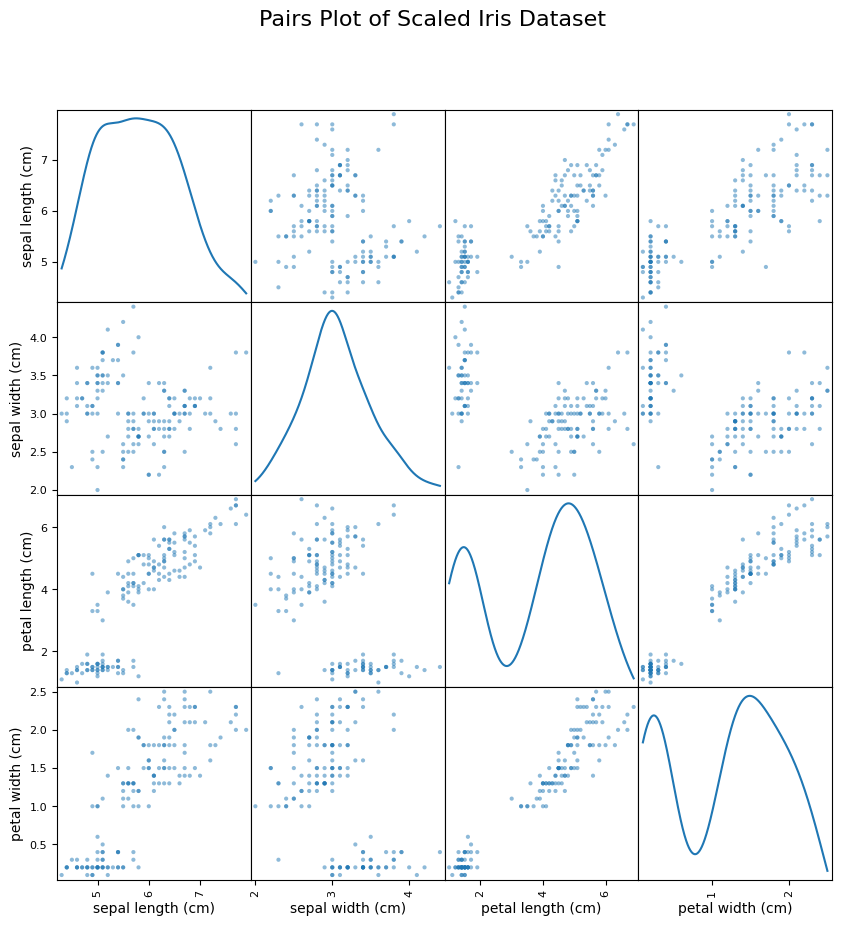

In [15]:
# pairs plots without plotting species
plt.figure(figsize=(10, 10))
pd.plotting.scatter_matrix(df_iris, figsize=(10, 10), diagonal='kde')
plt.suptitle('Pairs Plot of Scaled Iris Dataset', fontsize=16)
plt.show()


### K nearest neighbours
Using a train test split - remember to split before scaling

In [16]:
X_train, X_test, y_train, y_test = train_test_split(df_iris, iris.target, test_size=0.2, random_state=123) 
#df_iris has only numeric, iris has the target names (species), so we can use that for y

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
k_values = [1, 2, 3, 4, 5, 8, 10, 12, 15, 20]

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    y_pred = knn.predict(X_test_scaled)
    score = knn.score(X_test_scaled, y_test)
    
    print(f"k={k}, Test Accuracy: {score:.3f}")

k=1, Test Accuracy: 0.933
k=2, Test Accuracy: 0.900
k=3, Test Accuracy: 0.900
k=4, Test Accuracy: 0.900
k=5, Test Accuracy: 0.900
k=8, Test Accuracy: 0.900
k=10, Test Accuracy: 0.900
k=12, Test Accuracy: 0.900
k=15, Test Accuracy: 0.900
k=20, Test Accuracy: 0.867


In [ ]:
# split out train into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=123)